Importowanie danych

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(20000, 17)
liczba rekordow = 20000
liczba cech + etykieta = 17
rozklad kategorii = lettr
U    4.065
D    4.025
P    4.015
T    3.980
M    3.960
A    3.945
X    3.935
Y    3.930
N    3.915
Q    3.915
F    3.875
G    3.865
E    3.840
B    3.830
V    3.820
L    3.805
R    3.790
I    3.775
O    3.765
W    3.760
S    3.740
J    3.735
K    3.695
C    3.680
H    3.670
Z    3.670
Name: proportion, dtype: float64


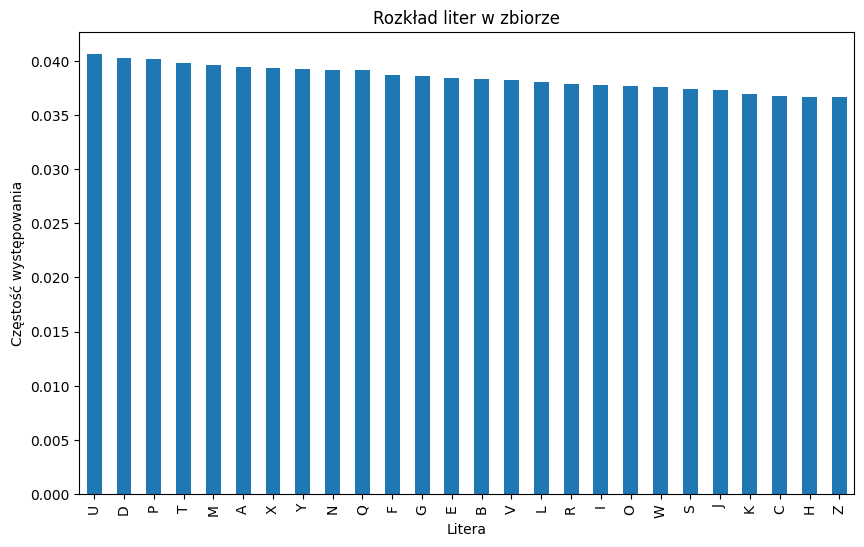

In [39]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix
path = path = '/content/drive/MyDrive/ProjektPRO'
import os
os.chdir(path)

#Variable Name dla zbioru 'letter-recognition.data'
columns = [
    'lettr', 'x-box', 'y-box', 'width', 'high', 'onpix', 'x-bar',
    'y-bar', 'x2bar', 'y2bar', 'xybar', 'x2ybr', 'xy2br', 'x-ege',
    'xegvy', 'y-ege', 'yegvx'
]

df = pd.read_csv('letter-recognition.data', header = None, names=columns)
print(df.shape)
df.head(10)
print(f"liczba rekordow = " + str(df.shape[0]))
print(f"liczba cech + etykieta = " + str(df.shape[1]))

print(f"rozklad kategorii = " + str(df['lettr'].value_counts(normalize=True)*100))

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
df['lettr'].value_counts(normalize=True).plot(kind='bar')
plt.title("Rozkład liter w zbiorze")
plt.xlabel("Litera")
plt.ylabel("Częstość występowania")

plt.show()

Normalizacja typu MinMax

In [40]:
from sklearn.preprocessing import MinMaxScaler


X = df.drop('lettr', axis=1)
y = df['lettr']

print("Przed normalizacja:")
print("min:\n", X.min())
print("\nmax:\n", X.max())

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

df_scaled = pd.concat([y.reset_index(drop=True),
                        X_scaled.reset_index(drop=True)],
                       axis=1)
print(df_scaled.head())
print("Po normalizacji:")
print("min:\n", X_scaled.min())
print("\nmax:\n", X_scaled.max())

Przed normalizacja:
min:
 x-box    0
y-box    0
width    0
high     0
onpix    0
x-bar    0
y-bar    0
x2bar    0
y2bar    0
xybar    0
x2ybr    0
xy2br    0
x-ege    0
xegvy    0
y-ege    0
yegvx    0
dtype: int64

max:
 x-box    15
y-box    15
width    15
high     15
onpix    15
x-bar    15
y-bar    15
x2bar    15
y2bar    15
xybar    15
x2ybr    15
xy2br    15
x-ege    15
xegvy    15
y-ege    15
yegvx    15
dtype: int64
  lettr     x-box     y-box  width      high     onpix     x-bar     y-bar  \
0     T  0.133333  0.533333    0.2  0.333333  0.066667  0.533333  0.866667   
1     I  0.333333  0.800000    0.2  0.466667  0.133333  0.666667  0.333333   
2     D  0.266667  0.733333    0.4  0.533333  0.400000  0.666667  0.400000   
3     N  0.466667  0.733333    0.4  0.400000  0.200000  0.333333  0.600000   
4     G  0.133333  0.066667    0.2  0.066667  0.066667  0.533333  0.400000   

      x2bar     y2bar     xybar     x2ybr     xy2br     x-ege     xegvy  \
0  0.000000  0.400000  0.4000

Podział danych na zbiór treningowy i testowy

In [41]:
# Zbiór treningowy: 16000 pierwszych liter
train = df_scaled.iloc[:16000]

# Zbiór testowy: kolejne 4000
test = df_scaled.iloc[16000:]


X_train = train.iloc[:, 1:] # Cechy
y_train = train.iloc[:, 0]  # Etykiety

X_test = test.iloc[:, 1:]
y_test = test.iloc[:, 0]


print("Treningowe cechy:", X_train.shape)
print("Testowe cechy:   ", X_test.shape)
print("Treningowe etykiety:", y_train.shape)
print("Testowe etykiety:   ", y_test.shape)



Treningowe cechy: (16000, 16)
Testowe cechy:    (4000, 16)
Treningowe etykiety: (16000,)
Testowe etykiety:    (4000,)


k-nn

In [42]:
import time
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

k_sasiadow = range(1, 11)
best_wynik = 0
best_k = 0
best_czas = 0

wyniki = []


for n in k_sasiadow:
    start = time.time()
    knn_clf = KNeighborsClassifier(n_neighbors=n)
    knn_clf.fit(X_train, y_train)

    predictions = knn_clf.predict(X_test)
    end = time.time()

    wynik = accuracy_score(y_test, predictions)
    czas = end - start

    wyniki.append(wynik)

    print(f"k: {n}, Dokładność: {wynik:.4f}, Czas: {czas:.3f}s")

    if wynik > best_wynik:
        best_wynik = wynik
        best_k = n
        best_czas = czas

knn_clf = KNeighborsClassifier(n_neighbors=best_k)
knn_clf.fit(X_train, y_train)

print(f"\nNajlepsza liczba najblizszych sasiadow: {best_k} z dokładnością: {best_wynik:.4f}")
print(f"Czas tego modelu: {best_czas:.3f}s")

final_predictions = knn_clf.predict(X_test)

print(f"\nRaport klasyfikacji dla najlepszego k={best_k}:")
print(classification_report(y_test, final_predictions))

k: 1, Dokładność: 0.9553, Czas: 0.679s
k: 2, Dokładność: 0.9413, Czas: 0.617s
k: 3, Dokładność: 0.9497, Czas: 0.648s
k: 4, Dokładność: 0.9470, Czas: 0.627s
k: 5, Dokładność: 0.9457, Czas: 0.549s
k: 6, Dokładność: 0.9493, Czas: 0.348s
k: 7, Dokładność: 0.9477, Czas: 0.358s
k: 8, Dokładność: 0.9465, Czas: 0.368s
k: 9, Dokładność: 0.9430, Czas: 0.366s
k: 10, Dokładność: 0.9423, Czas: 0.379s

Najlepsza liczba najblizszych sasiadow: 1 z dokładnością: 0.9553
Czas tego modelu: 0.679s

Raport klasyfikacji dla najlepszego k=1:
              precision    recall  f1-score   support

           A       0.99      0.99      0.99       156
           B       0.91      0.95      0.93       136
           C       0.96      0.96      0.96       142
           D       0.94      0.97      0.95       167
           E       0.96      0.92      0.94       152
           F       0.92      0.92      0.92       153
           G       0.96      0.96      0.96       164
           H       0.91      0.89      0.90

Diagram dokładności k-NN w zależności od liczby sąsiadów (k)

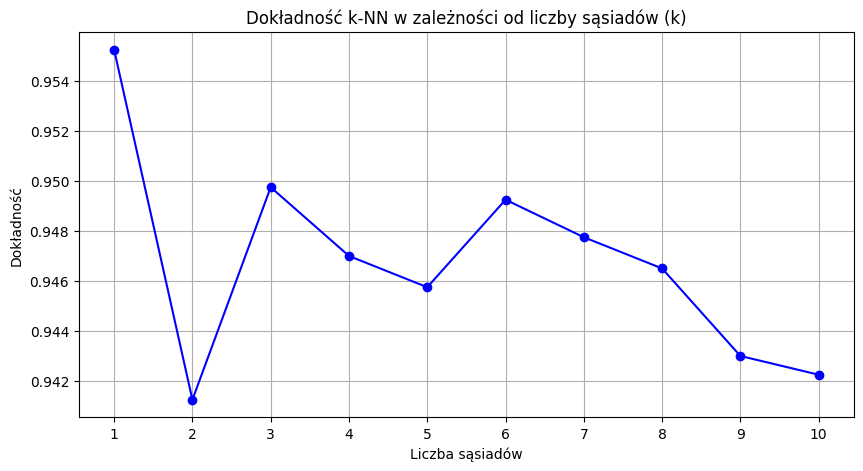

In [43]:
plt.figure(figsize=(10, 5))
plt.plot(k_sasiadow, wyniki, marker='o', linestyle='-', color='b')
plt.title('Dokładność k-NN w zależności od liczby sąsiadów (k)')
plt.xlabel('Liczba sąsiadów')
plt.ylabel('Dokładność')
plt.grid(True)
plt.xticks(k_sasiadow)
plt.show()

Trafność w klasyfikacji liter przez k-NN

In [44]:
import numpy as np

print("\nAccuracy dla każdej litery:")
classes = np.unique(y_test)
cm = confusion_matrix(y_test, final_predictions, labels=classes)

for i, cls in enumerate(classes):
    cls_accuracy = cm[i, i] / cm[i].sum()
    print(f"{cls}: {cls_accuracy * 100:.2f}%")


Accuracy dla każdej litery:
A: 98.72%
B: 94.85%
C: 95.77%
D: 97.01%
E: 92.11%
F: 91.50%
G: 96.34%
H: 88.74%
I: 96.97%
J: 93.92%
K: 91.10%
L: 96.82%
M: 97.22%
N: 94.58%
O: 97.12%
P: 93.45%
Q: 95.83%
R: 91.30%
S: 97.52%
T: 96.69%
U: 98.81%
V: 99.26%
W: 97.84%
X: 95.60%
Y: 96.55%
Z: 98.10%


Macierz pomyłek dla k-NN

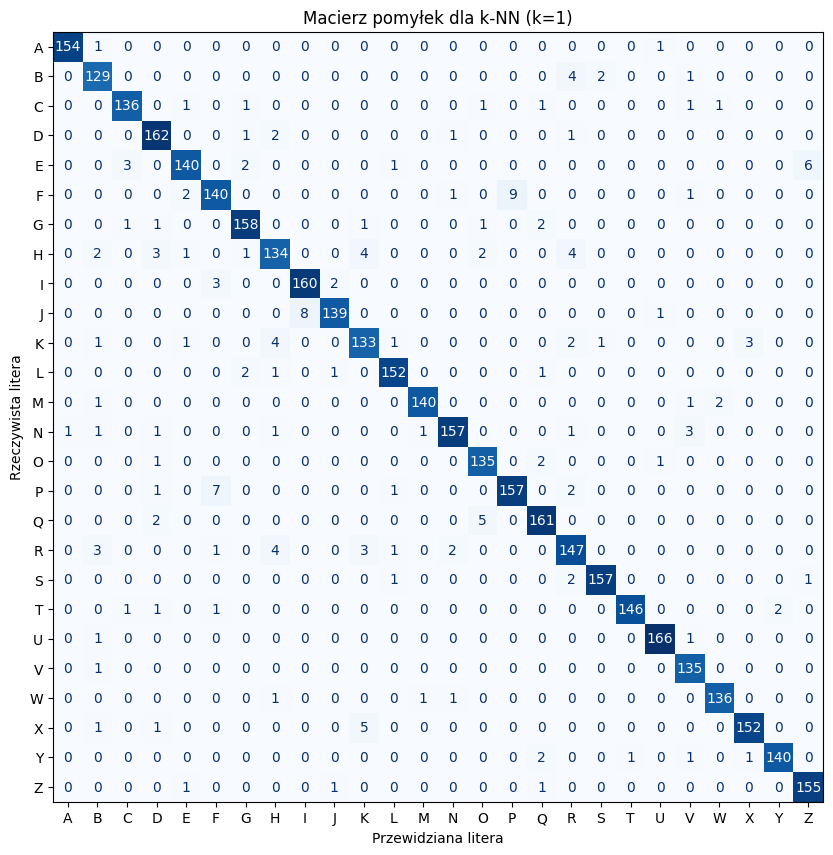

In [45]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = knn_clf.predict(X_test)

fig, ax = plt.subplots(figsize=(10, 10))


ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    ax=ax,
    cmap='Blues',
    colorbar=False
)

plt.title(f"Macierz pomyłek dla k-NN (k={best_k})")
plt.xlabel('Przewidziana litera')
plt.ylabel('Rzeczywista litera')
plt.show()

Klasyfikator Bayesowski
Wybrano wariant Gaussowski ze względu na to że cechy są wartościami ciągłymi

Klasyfikowanie za pomocą modelu GaussianNB

In [46]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import time
import numpy as np
start= time.time()
gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred = gnb.predict(X_test)
end= time.time()
endtime= end- start
accuracy = accuracy_score(y_test, y_pred)


print(f"Dokładność (Accuracy): {accuracy * 100:.2f}%")
print("------------------------------")
print("Accuracy dla każdej litery:")
cm = confusion_matrix(y_test, y_pred)
classes = np.unique(y_test)
for i, cls in enumerate(classes):
    cls_accuracy = cm[i, i] / cm[i].sum()
    print(f"{cls}: {cls_accuracy * 100:.2f}%")
print("------------------------------")
print(f"Czas wykonania: {endtime:.2f} sekund")
print("------------------------------")
print("\nRaport klasyfikacji:")
print(classification_report(y_test, y_pred))

Dokładność (Accuracy): 62.52%
------------------------------
Accuracy dla każdej litery:
A: 83.97%
B: 66.18%
C: 73.24%
D: 68.86%
E: 38.16%
F: 73.20%
G: 57.32%
H: 27.15%
I: 78.18%
J: 74.32%
K: 45.21%
L: 74.52%
M: 89.58%
N: 57.23%
O: 66.91%
P: 72.02%
Q: 55.36%
R: 65.22%
S: 27.95%
T: 68.87%
U: 67.86%
V: 77.21%
W: 76.98%
X: 50.31%
Y: 34.48%
Z: 58.86%
------------------------------
Czas wykonania: 0.05 sekund
------------------------------

Raport klasyfikacji:
              precision    recall  f1-score   support

           A       0.83      0.84      0.84       156
           B       0.45      0.66      0.54       136
           C       0.76      0.73      0.75       142
           D       0.54      0.69      0.60       167
           E       0.67      0.38      0.49       152
           F       0.68      0.73      0.71       153
           G       0.54      0.57      0.56       164
           H       0.50      0.27      0.35       151
           I       0.55      0.78      0.65       16

Obliczanie różnych miar wraz z wizualizacją na macierzy pomyłek

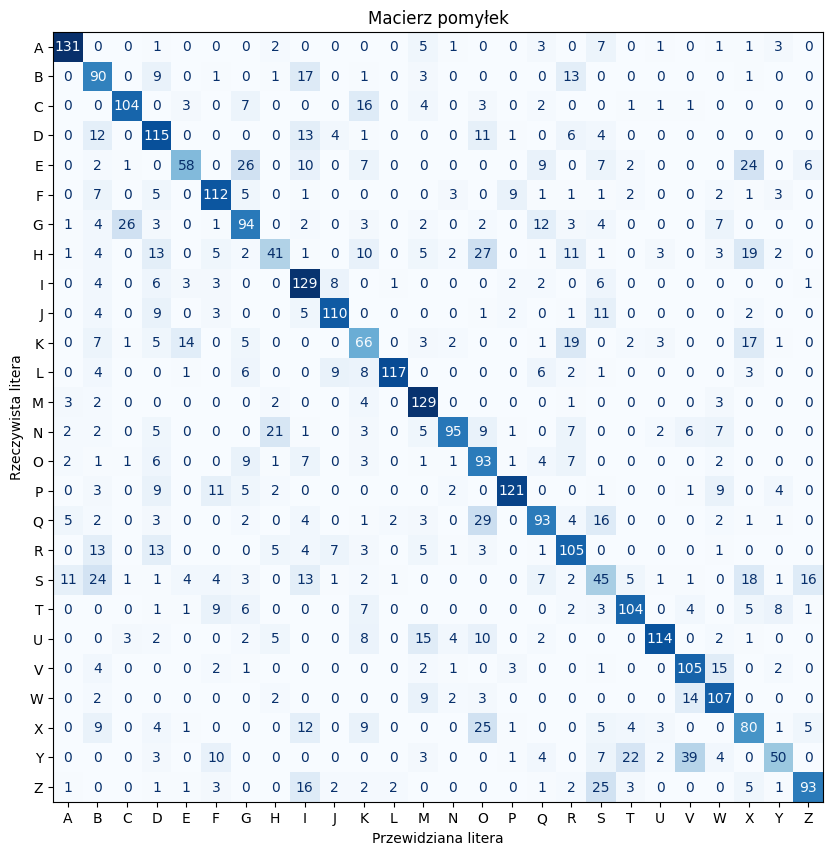

In [47]:
fig, ax = plt.subplots(figsize=(10, 10))


ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    ax=ax,
    cmap='Blues',
    colorbar=False
)
plt.title('Macierz pomyłek')
plt.xlabel('Przewidziana litera')
plt.ylabel('Rzeczywista litera')
plt.show()

In [48]:
from sklearn.ensemble import RandomForestClassifier

best_accuracy = 0
best_params = {}
results = []

for depth in [10, 20,30]:
     for criterion in ['gini', 'entropy', 'log_loss']:
         model = RandomForestClassifier(max_depth=depth, criterion=criterion, random_state=42)
         model.fit(X_train, y_train)
         accuracy = model.score(X_test, y_test)
         if(accuracy > best_accuracy):
           best_accuracy = accuracy
           best_params = {'max_depth': depth, 'criterion': criterion}

         print(f"Depth: {depth}, Criterion: {criterion}, Accuracy: {accuracy:.4f}")

print(f"Best Accuracy: {best_accuracy:.4f}")
print(f"Best Parameters: {best_params}")

start = time.time()

tree_clf = RandomForestClassifier(**best_params, random_state=42)
tree_clf.fit(X_train, y_train)

stop = time.time()
endtime = stop - start

y_pred = tree_clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Dokładność (Accuracy): {accuracy * 100:.2f}%")
print("------------------------------")
print("Accuracy dla każdej litery:")
cm = confusion_matrix(y_test, y_pred)
classes = np.unique(y_test)
for i, cls in enumerate(classes):
    cls_accuracy = cm[i, i] / cm[i].sum()
    print(f"{cls}: {cls_accuracy * 100:.2f}%")
print("------------------------------")
print(f"Czas wykonania: {endtime:.2f} sekund")
print("------------------------------")
print("\nRaport klasyfikacji:")
print(classification_report(y_test, y_pred))

Depth: 10, Criterion: gini, Accuracy: 0.8515
Depth: 10, Criterion: entropy, Accuracy: 0.9157
Depth: 10, Criterion: log_loss, Accuracy: 0.9157
Depth: 20, Criterion: gini, Accuracy: 0.9590
Depth: 20, Criterion: entropy, Accuracy: 0.9627
Depth: 20, Criterion: log_loss, Accuracy: 0.9627
Depth: 30, Criterion: gini, Accuracy: 0.9645
Depth: 30, Criterion: entropy, Accuracy: 0.9633
Depth: 30, Criterion: log_loss, Accuracy: 0.9633
Best Accuracy: 0.9645
Best Parameters: {'max_depth': 30, 'criterion': 'gini'}
Dokładność (Accuracy): 96.45%
------------------------------
Accuracy dla każdej litery:
A: 98.72%
B: 97.79%
C: 97.18%
D: 98.80%
E: 97.37%
F: 98.04%
G: 95.73%
H: 90.07%
I: 93.94%
J: 94.59%
K: 92.47%
L: 95.54%
M: 100.00%
N: 93.37%
O: 96.40%
P: 95.83%
Q: 96.43%
R: 96.27%
S: 97.52%
T: 98.68%
U: 98.21%
V: 96.32%
W: 98.56%
X: 96.86%
Y: 96.55%
Z: 96.84%
------------------------------
Czas wykonania: 2.63 sekund
------------------------------

Raport klasyfikacji:
              precision    recall 

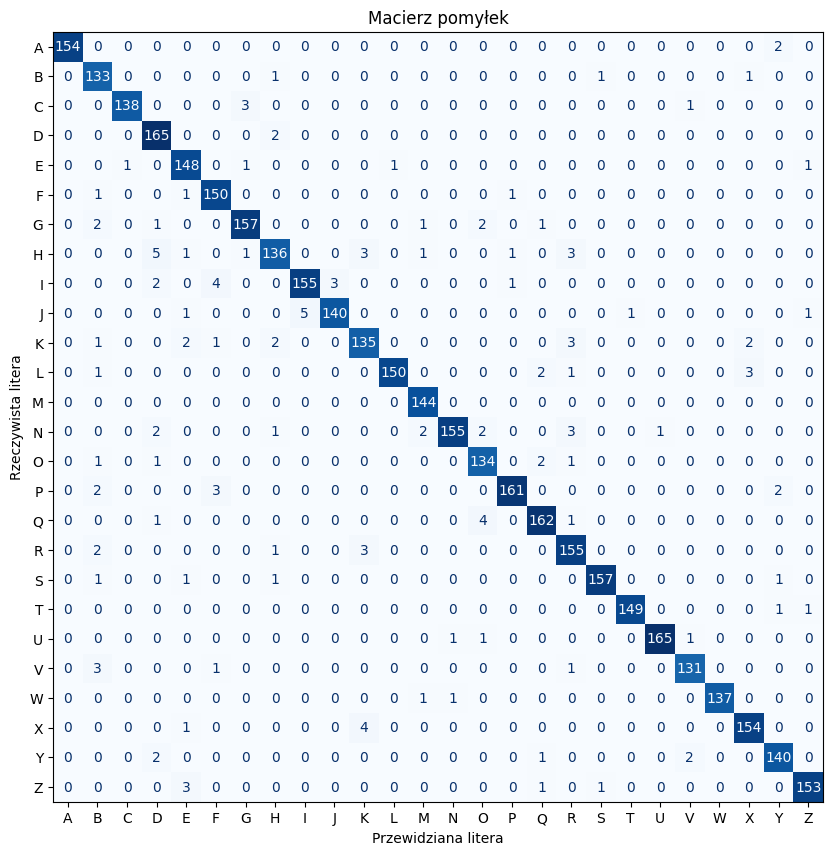

In [49]:
fig, ax = plt.subplots(figsize=(10, 10))


ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    ax=ax,
    cmap='Blues',
    colorbar=False
)
plt.title('Macierz pomyłek')
plt.xlabel('Przewidziana litera')
plt.ylabel('Rzeczywista litera')
plt.show()

Porównanie obu modeli

Bayes                                            | K-NN (k=1)                                 | Random Forest

Accuracy: 62.52%                       | 95.53%                                        | 96.45%

Czas wykonania: 0.05s              | 0.805s                                         | 2.36s

Precision: 0.64                            | 0.96                                              | 0.97

Recall: 0.63                                  | 0.96                                              | 0.96

F1-score: 0.62                              | 0.96                                              | 0.96

Support: 4000                             | 4000                                             | 4000

Accuracy dla liter:                        |                                                      |

A: 83.97%                                             | 98.72%                                           | 98.72%

B: 66.18%                                             | 94.85%                                           | 97.79%

C: 73.24%                                             | 95.77%                                           | 97.18%

D: 68.86%                                             | 97.01%                                           | 98.80%

E: 38.16%                                             | 92.11%                                           | 97.37%

F: 73.20%                                             | 91.50%                                           | 98.04%

G: 57.32%                                             | 96.34%                                           | 95.73%

H: 27.15%                                             | 88.74%                                           | 90.07%

I: 78.18%                                              | 96.97%                                           | 93.94%

J: 74.32%                                              | 93.92%                                           | 94.59%

K: 45.21%                                             | 91.10%                                           | 92.47%

L: 74.52%                                             | 96.82%                                           | 95.54%

M: 89.58%                                            | 97.22%                                           | 100.00%

N: 57.23%                                             | 94.58%                                           | 93.37%

O: 66.91%                                             | 97.12%                                           | 96.40%

P: 72.02%                                             | 93.45%                                           | 95.83%

Q: 55.36%                                             | 95.83%                                           | 96.43%

R: 65.22%                                             | 91.30%                                           | 96.27%

S: 27.95%                                             | 97.52%                                           | 97.52%

T: 68.87%                                             | 96.69%                                           | 98.68%

U: 67.86%                                             | 98.81%                                           | 98.21%

V: 77.21%                                              | 99.26%                                           | 96.32%

W: 76.98%                                             | 97.84%                                           | 98.56%

X: 50.31%                                             | 95.60%                                           | 96.86%

Y: 34.48%                                             | 96.55%                                           | 96.55%

Z: 58.86%                                             | 98.10%                                           | 96.84%

Pierwszą rzeczą którą możemy zauważyć jest to że klasyfikator Bayesa znacząco odstaje jakością od pozostałych. Dzieje się tak ponieważ nie jest to klasyfikator przeznaczony do tego typu danych i jego gorszy wynik jest czymś oczekiwanym. Wiedząc to porównajmy pozostałe 2 modele.

Modelem z najwyższą średnią precyzją jest Random Forest. K-NN jest gorszy jedynie o ok. 1 punkt procentowy. Natomiast plusem K-NN jest jego szybkość trenowania oraz predykcji w porównaniu do Random Forest.

Różnica w precyzji między Random Forest a K-NN nie jest duża, oba modele radzą sobie równie dobrze z rozpoznawaniem liter. Sugerując się czasem stwierdzamy, że K-NN jest najlepszy dla tego typu zadań.